# T43 — Paleolatitude via reverse reconstruction: what latitude was each modern location at in deep time?

**Cluster F: Paleomagnetism.**  *Adapted with permission from:* Adam Kocsis's [`pyGMTexamples/paleolat.R`](https://github.com/adamkocsis/pyGMTexamples).

## What this notebook produces

A **modern-day map coloured by paleo-latitude at a chosen deep-time age**. Every location on Earth's current land surface is coloured by the latitude it *occupied* at, say, 80 Ma. Red = northern high latitudes back then; blue = southern high latitudes. The visualisation makes it immediately obvious how much a continent has drifted (or barely moved) between the target age and today — India was at ~-40° in the Late Cretaceous; northern Europe was already close to its current latitude; Australia was hard against Antarctica; and so on.

This is a **reverse reconstruction**: we start with a uniform sample of points on today's Earth, use the plate model to determine each point's plate at the target age, and rotate that plate BACKWARDS through time to recover the paleo-position of each point.

The three panels the notebook produces:
1. **Present-day map with per-point paleolatitude dots.** Kocsis-style scatter of \~30k Fibonacci-sphere points, each coloured by its paleo-latitude.
2. **Continuous IDW-interpolated paleolatitude grid.** Same information as (1), interpolated onto a regular 0.5° grid.
3. **Climate-belt version.** The IDW grid classified into five belts (polar / temperate / tropical / temperate / polar) so the reader sees at a glance which zones each modern land mass belonged to.

## Learning objectives

- Use `gplately.Points(..., time=age)` to initialise a point set at a paleo age and reconstruct it to present as a **reverse reconstruction**.
- Generate a uniform sample of points on a sphere with a Fibonacci lattice (avoids the pole-clustering artefacts of `np.random`).
- Mask to modern land via `regionmask` + Natural Earth coastlines, or via a lookup against a coastline shapefile.
- Interpolate scattered paleolatitude values onto a regular grid with inverse-distance-weighted (IDW) interpolation (scipy).
- Render each product with pure pyGMT.

## Prerequisites and runtime

- **Plate model**: Merdith 2021 (paleomag frame, anchor plate 0). Matches Kocsis's example. Swap `MODEL_NAME` for any other paleomag-frame model in the CONFIGURATION cell.
- **Time**: target-paleo-age is user-set; default 80 Ma (Late Cretaceous / Campanian) mirrors Kocsis.
- **Python**: `gplately`, `pygmt`, `numpy`, `pandas`, `xarray`, `shapely`, `scipy`.
- **Runtime**: \~30 s for N_POINTS = 30 000. Scale linearly with N_POINTS.


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager
from scipy.spatial import cKDTree

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  xarray      2026.7.0
  pygmt       v0.17.0
  gplately    2.0.0
  pygplates   1.0.0


## Configuration


In [2]:
# === USER CONFIGURATION =====================================================
# Paleomag-frame plate model (Kocsis uses MERDITH2021). Any paleomag-frame
# model works; Zahirovic2022 with anchor 701701 also fine at <=410 Ma.
MODEL_NAME           = "Merdith2021"
ANCHOR_PLATE_ID      = 0             # M21's default rotation IS the paleomag frame

# The paleo age at which each modern location's paleolatitude is measured.
PALEO_AGE_MA         = 80.0          # Late Cretaceous / Campanian (Kocsis default)

# Uniform sphere sample. 30k dots is Kocsis's density; scale up for smoother
# maps at the cost of runtime.
N_POINTS             = 30_000

# IDW interpolation grid resolution + search radius (in degrees).
GRID_RES_DEG         = 0.5
IDW_RADIUS_DEG       = 8.0           # sample no more than 8 deg away when interpolating
IDW_K_NEIGHBOURS     = 8             # blend the K nearest samples via 1/d weighting

# Climate-belt cuts for panel 3.
CLIMATE_BELTS_DEG    = [-90, -60, -30, 30, 60, 90]

# Map layout — Winkel Tripel to minimise polar distortion.
REGION, PROJ         = [-180, 180, -90, 90], "R0/22c"
# ============================================================================
print(f"  model:          {MODEL_NAME}  (anchor plate {ANCHOR_PLATE_ID})")
print(f"  paleo age:      {PALEO_AGE_MA:.0f} Ma")
print(f"  N points:       {N_POINTS:,}")
print(f"  grid resolution:{GRID_RES_DEG}°")


  model:          Merdith2021  (anchor plate 0)
  paleo age:      80 Ma
  N points:       30,000
  grid resolution:0.5°


## 1. Load the plate model


In [3]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
print(f"  {MODEL_NAME} loaded")


  Merdith2021 loaded


## 2. Fibonacci-sphere sample — uniform points on Earth

A Fibonacci-lattice sample is the standard way to place N points quasi-uniformly on a sphere without the pole-clustering that plagues `np.random.uniform` in (lat, lon). Each point sits at a golden-angle-offset azimuth on a latitude that increments in equal solid-angle steps.

In [4]:
def fibonacci_sphere(n: int) -> tuple[np.ndarray, np.ndarray]:
    """Return (lons, lats) of N uniformly-distributed points on the sphere."""
    i    = np.arange(n) + 0.5
    phi  = np.arccos(1 - 2 * i / n)                     # colatitude in [0, pi]
    lam  = np.mod(np.pi * (1 + 5 ** 0.5) * i, 2 * np.pi)  # longitude, golden-angle stepped
    lats = 90.0 - np.degrees(phi)
    lons = np.degrees(lam) - 180.0                       # centre on 0
    return lons, lats


sample_lons, sample_lats = fibonacci_sphere(N_POINTS)
print(f"  {len(sample_lons):,} Fibonacci sphere points "
      f"(lon {sample_lons.min():.1f}..{sample_lons.max():.1f}, "
      f"lat {sample_lats.min():.1f}..{sample_lats.max():.1f})")


  30,000 Fibonacci sphere points (lon -180.0..180.0, lat -89.5..89.5)


## 3. Reverse reconstruction — label each modern point with its paleolatitude at PALEO_AGE_MA

The workflow in one line: assign each modern point to a plate (via the model's static polygons), then use the model's rotations to determine what latitude that plate WAS at at `PALEO_AGE_MA`. The `gplately.Points` helper does the plate-lookup and rotation for us.

In [5]:
# Present-day points — gplately assigns each to a plate via static polygons.
gpts = gplately.Points(recon, sample_lons, sample_lats,
                       anchor_plate_id=ANCHOR_PLATE_ID)

# Reconstruct FORWARD from present to PALEO_AGE_MA gives each point's paleo
# position at that age — which is exactly the paleolatitude Kocsis's R code
# computes with `reconstruct(p, from=age, age=0)` in reverse.
plons, plats = gpts.reconstruct(float(PALEO_AGE_MA),
                                return_array=True,
                                anchor_plate_id=ANCHOR_PLATE_ID)

df = pd.DataFrame({
    "modern_lon": sample_lons,
    "modern_lat": sample_lats,
    "paleo_lon":  plons,
    "paleo_lat":  plats,
})
df_valid = df.dropna(subset=["paleo_lat"]).copy()
print(f"  {len(df_valid):,} / {len(df):,} points have a valid paleo-position at {PALEO_AGE_MA:.0f} Ma")
print(f"  paleolatitude range: {df_valid['paleo_lat'].min():.1f}° to {df_valid['paleo_lat'].max():.1f}°")


  30,000 / 30,000 points have a valid paleo-position at 80 Ma
  paleolatitude range: -89.8° to 89.6°


## 4. Present-day map — land-only paleolatitude dots

Kocsis's map filters the sample to modern coastlines so the coloured dots only appear on land. We do the same via a coarse continent test: keep only points whose modern position falls inside a GSHHG-derived land mask sampled at 1°.

In [6]:
# Query GMT's GSHHG database for a land mask by using pygmt.grdlandmask.
# 1 = land, NaN = ocean, at 1° resolution.
land_mask = pygmt.grdlandmask(region=REGION, spacing="0.5d",
                              maskvalues=["NaN", 1, 1, 1, 1])
# Now sample the mask at each modern-day sample point.
def is_land(lons, lats):
    # nearest-neighbour lookup in the mask DataArray
    sampled = land_mask.interp(lon=xr.DataArray(lons, dims="i"),
                               lat=xr.DataArray(lats, dims="i"),
                               method="nearest").values
    return np.isfinite(sampled)

on_land = is_land(df_valid["modern_lon"].to_numpy(),
                  df_valid["modern_lat"].to_numpy())
df_land = df_valid[on_land].reset_index(drop=True)
print(f"  {len(df_land):,} of {len(df_valid):,} points land only")


  8,762 of 30,000 points land only


## 5. Panel 1 — present-day map coloured by paleolatitude (per-point dots)


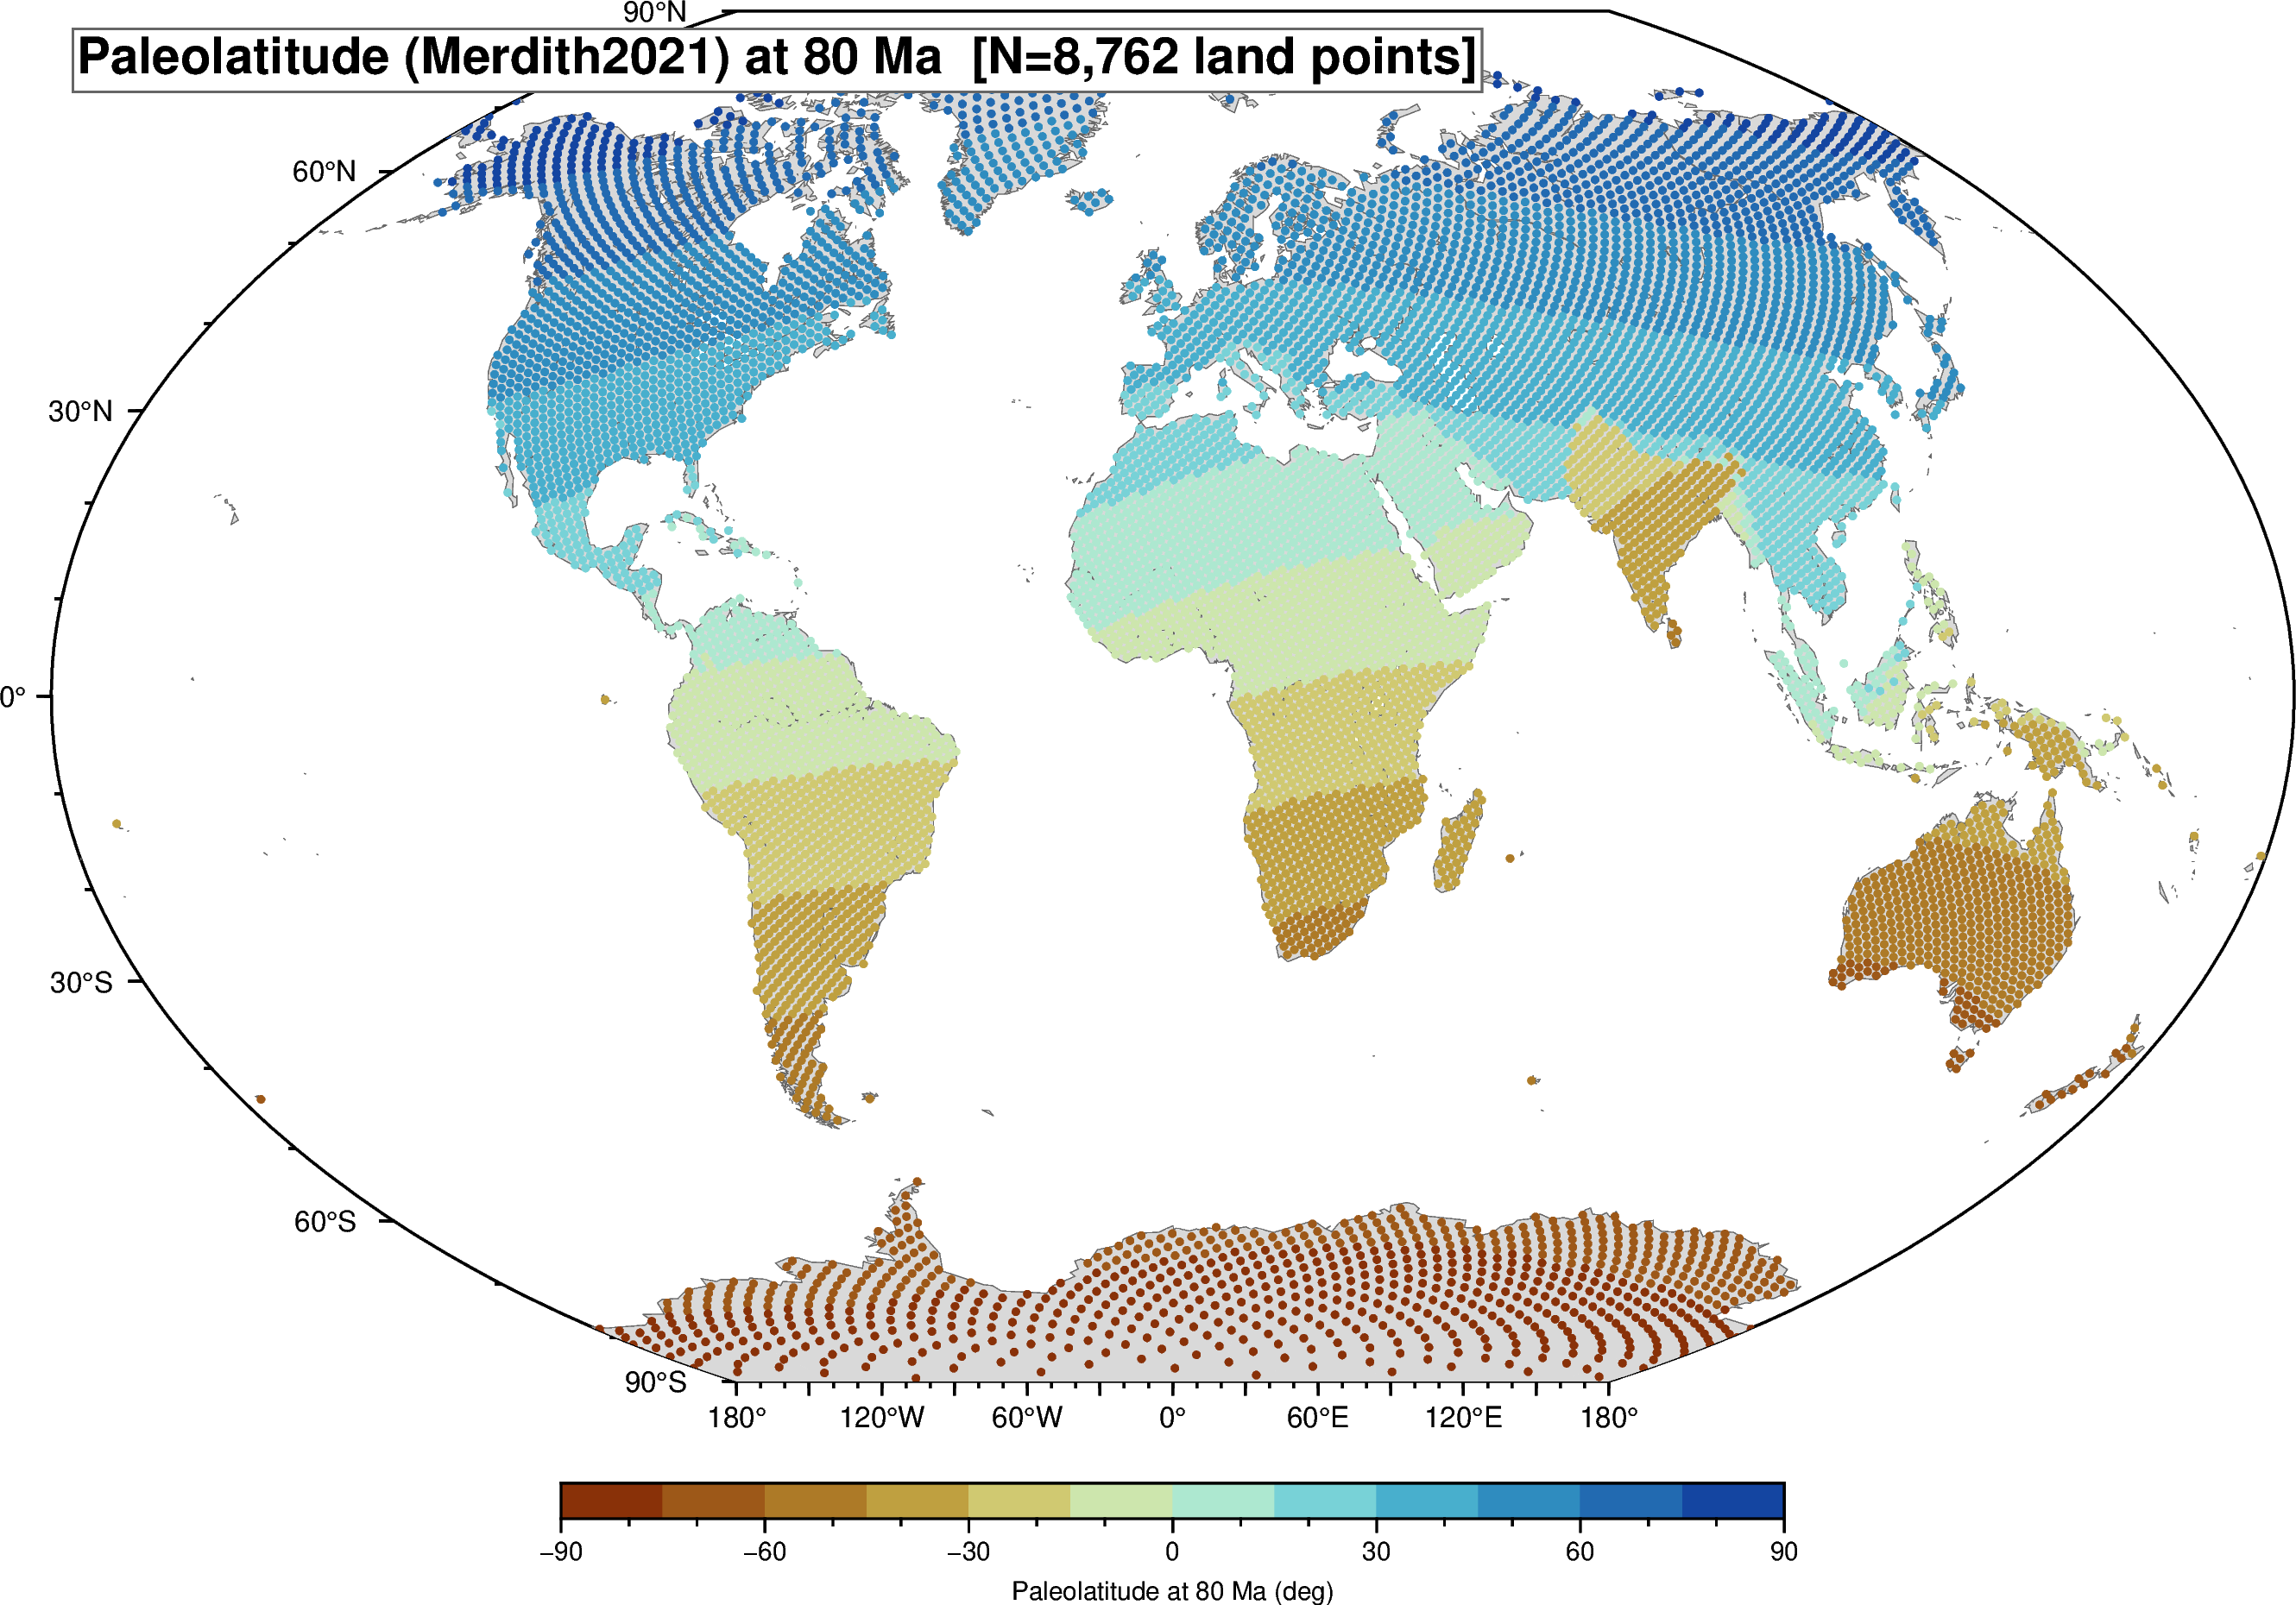

In [7]:
# CPT: diverging on paleolatitude, from -90° (deep blue = south polar) to
# +90° (deep red = north polar).
import tempfile
_fd, cpt_path = tempfile.mkstemp(suffix=".cpt", prefix="T73_paleolat_")
os.close(_fd)
pygmt.makecpt(cmap="roma", series=[-90, 90, 15], reverse=False, output=cpt_path)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(land="gray85", shorelines="0.2p,gray40")     # present-day GSHHG (this IS a present-day map)

xyz = np.column_stack([
    df_land["modern_lon"].to_numpy(),
    df_land["modern_lat"].to_numpy(),
    df_land["paleo_lat"].to_numpy(),
])
fig.plot(data=xyz, style="c0.08c", cmap=cpt_path)

fig.colorbar(cmap=cpt_path,
             position="JBC+w12c/0.35c+h+o0/1c",
             frame=["a30f10", f"x+lPaleolatitude at {PALEO_AGE_MA:.0f} Ma (deg)"])
fig.text(text=f"Paleolatitude ({MODEL_NAME}) at {PALEO_AGE_MA:.0f} Ma  "
              f"[N={len(df_land):,} land points]",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read this map

Every dot sits on its **modern** longitude/latitude but is coloured by its **paleo** latitude at the target age. Cool colours (blue) = southern latitudes at PALEO_AGE_MA; warm (red) = northern. Neutral cream = paleoequator.

Look for continents that have drifted a lot (dot colour differs from the current latitude band — e.g. **India** at 80 Ma was in the deep southern subtropics, still hundreds of km south of the equator on its way north; **Australia** was well south, near Antarctica). Look for continents that have barely moved (dot colour matches the current latitude band — e.g. **northern Eurasia**, **the Canadian shield**). The strong left-right smearing across northern North America and Asia reflects small rotation adjustments across each continent's rigid interior.

## 6. Panel 2 — continuous IDW-interpolated paleolatitude grid

Kocsis notes that a continuous paleolatitude field is *technically* not correct (paleolatitude has discontinuities across plate boundaries), but it's much more legible on a small screen. We interpolate the land-only paleolat samples onto a regular 0.5° grid with inverse-distance-weighting (K nearest neighbours) and mask to modern land.


In [8]:
# Build the target grid.
lon_axis = np.arange(-180, 180 + GRID_RES_DEG, GRID_RES_DEG)
lat_axis = np.arange(-90,  90  + GRID_RES_DEG, GRID_RES_DEG)
GLON, GLAT = np.meshgrid(lon_axis, lat_axis)

# IDW via cKDTree on unit-sphere Cartesian coords so the search radius is
# an actual arc-distance (deg on the sphere), not a lon-lat rectangle.
def _to_xyz(lons, lats):
    lat_r, lon_r = np.radians(lats), np.radians(lons)
    return np.column_stack([np.cos(lat_r) * np.cos(lon_r),
                            np.cos(lat_r) * np.sin(lon_r),
                            np.sin(lat_r)])

sample_xyz = _to_xyz(df_land["modern_lon"].to_numpy(),
                     df_land["modern_lat"].to_numpy())
grid_xyz   = _to_xyz(GLON.ravel(), GLAT.ravel())
tree       = cKDTree(sample_xyz)

# For each grid cell, find K nearest samples within the radius.
radius_chord = 2 * np.sin(np.radians(IDW_RADIUS_DEG) / 2)
dist, idx    = tree.query(grid_xyz, k=IDW_K_NEIGHBOURS,
                          distance_upper_bound=radius_chord)

# IDW weights (1/d, capped for the singularity at d=0)
weights = 1.0 / np.maximum(dist, 1e-9)
# Cells with no neighbour in range have all-inf distances — mark as NaN
all_inf = np.all(np.isinf(dist), axis=1)
weights[np.isinf(dist)] = 0.0
denom = weights.sum(axis=1)
denom[denom == 0] = 1.0

# Look up paleolat per neighbour, protecting against out-of-range indices
safe_idx = np.where(idx >= len(df_land), 0, idx)
sample_paleolat = df_land["paleo_lat"].to_numpy()
gathered = sample_paleolat[safe_idx]
gathered[np.isinf(dist)] = 0.0    # zero-out the sentinel neighbours

grid_paleolat = (gathered * weights).sum(axis=1) / denom
grid_paleolat[all_inf] = np.nan
grid_paleolat = grid_paleolat.reshape(GLON.shape)

# Mask to modern land.
grid_land = pygmt.grdlandmask(region=REGION, spacing=f"{GRID_RES_DEG}d",
                              maskvalues=["NaN", 1, 1, 1, 1])
# Align coords — interp onto GLON/GLAT nodes
land_here = grid_land.interp(lon=xr.DataArray(lon_axis, dims="lon"),
                             lat=xr.DataArray(lat_axis, dims="lat"),
                             method="nearest").values
grid_paleolat = np.where(np.isfinite(land_here), grid_paleolat, np.nan)

da_paleolat = xr.DataArray(grid_paleolat.astype(np.float32),
                            dims=("y", "x"),
                            coords={"y": lat_axis.astype(np.float32),
                                    "x": lon_axis.astype(np.float32)},
                            name="paleolat")
da_paleolat.gmt.registration = 0
da_paleolat.gmt.gtype        = 1     # geographic (lon, lat)
print(f"  interpolated grid: {da_paleolat.shape}, land coverage {int(np.isfinite(grid_paleolat).sum()):,} cells")


  interpolated grid: (361, 721), land coverage 88,630 cells


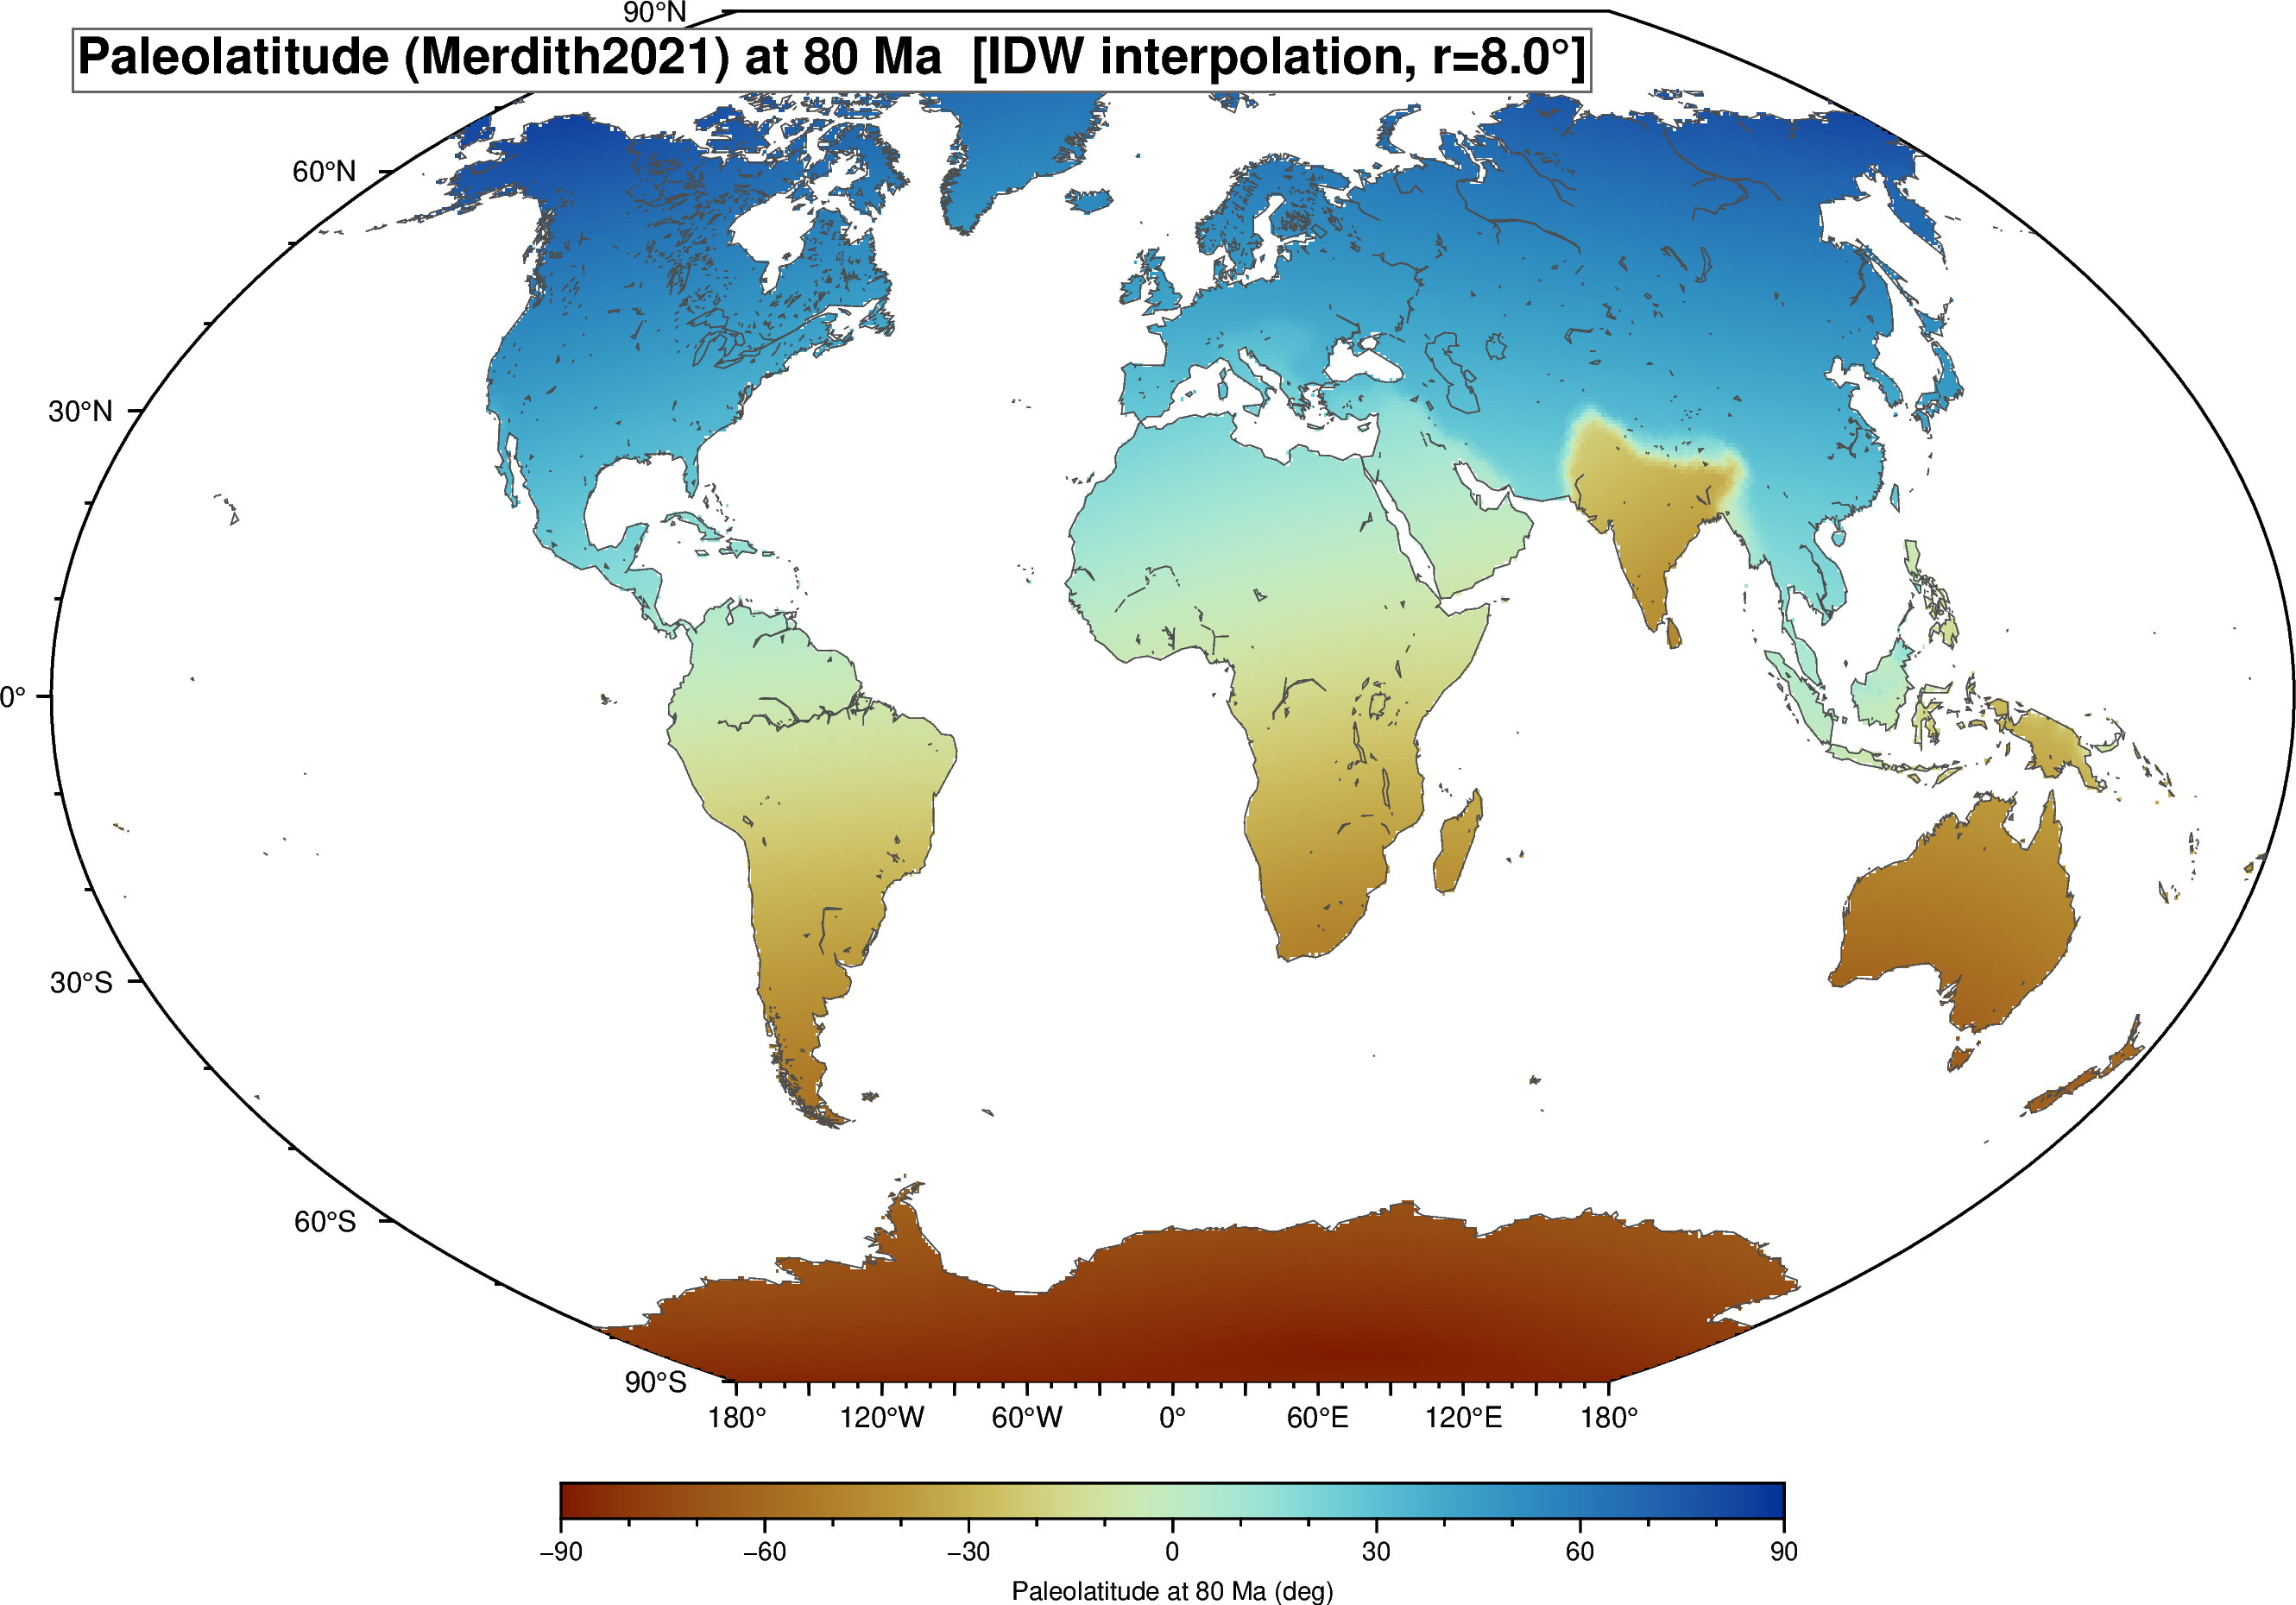

In [9]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
pygmt.makecpt(cmap="roma", series=[-90, 90, 5], continuous=True)
fig.grdimage(grid=da_paleolat, cmap=True, nan_transparent=True)
fig.coast(land=None, shorelines="0.3p,gray30")
fig.colorbar(frame=["a30f10", f"x+lPaleolatitude at {PALEO_AGE_MA:.0f} Ma (deg)"],
             position="JBC+w12c/0.35c+h+o0/1c")
fig.text(text=f"Paleolatitude ({MODEL_NAME}) at {PALEO_AGE_MA:.0f} Ma  [IDW interpolation, r={IDW_RADIUS_DEG}°]",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 7. Panel 3 — climate-belt version (5 zones, polar / temperate / tropical)

The IDW paleolatitude grid discretised into five climate zones so the biogeographic + climatic reading is immediate.

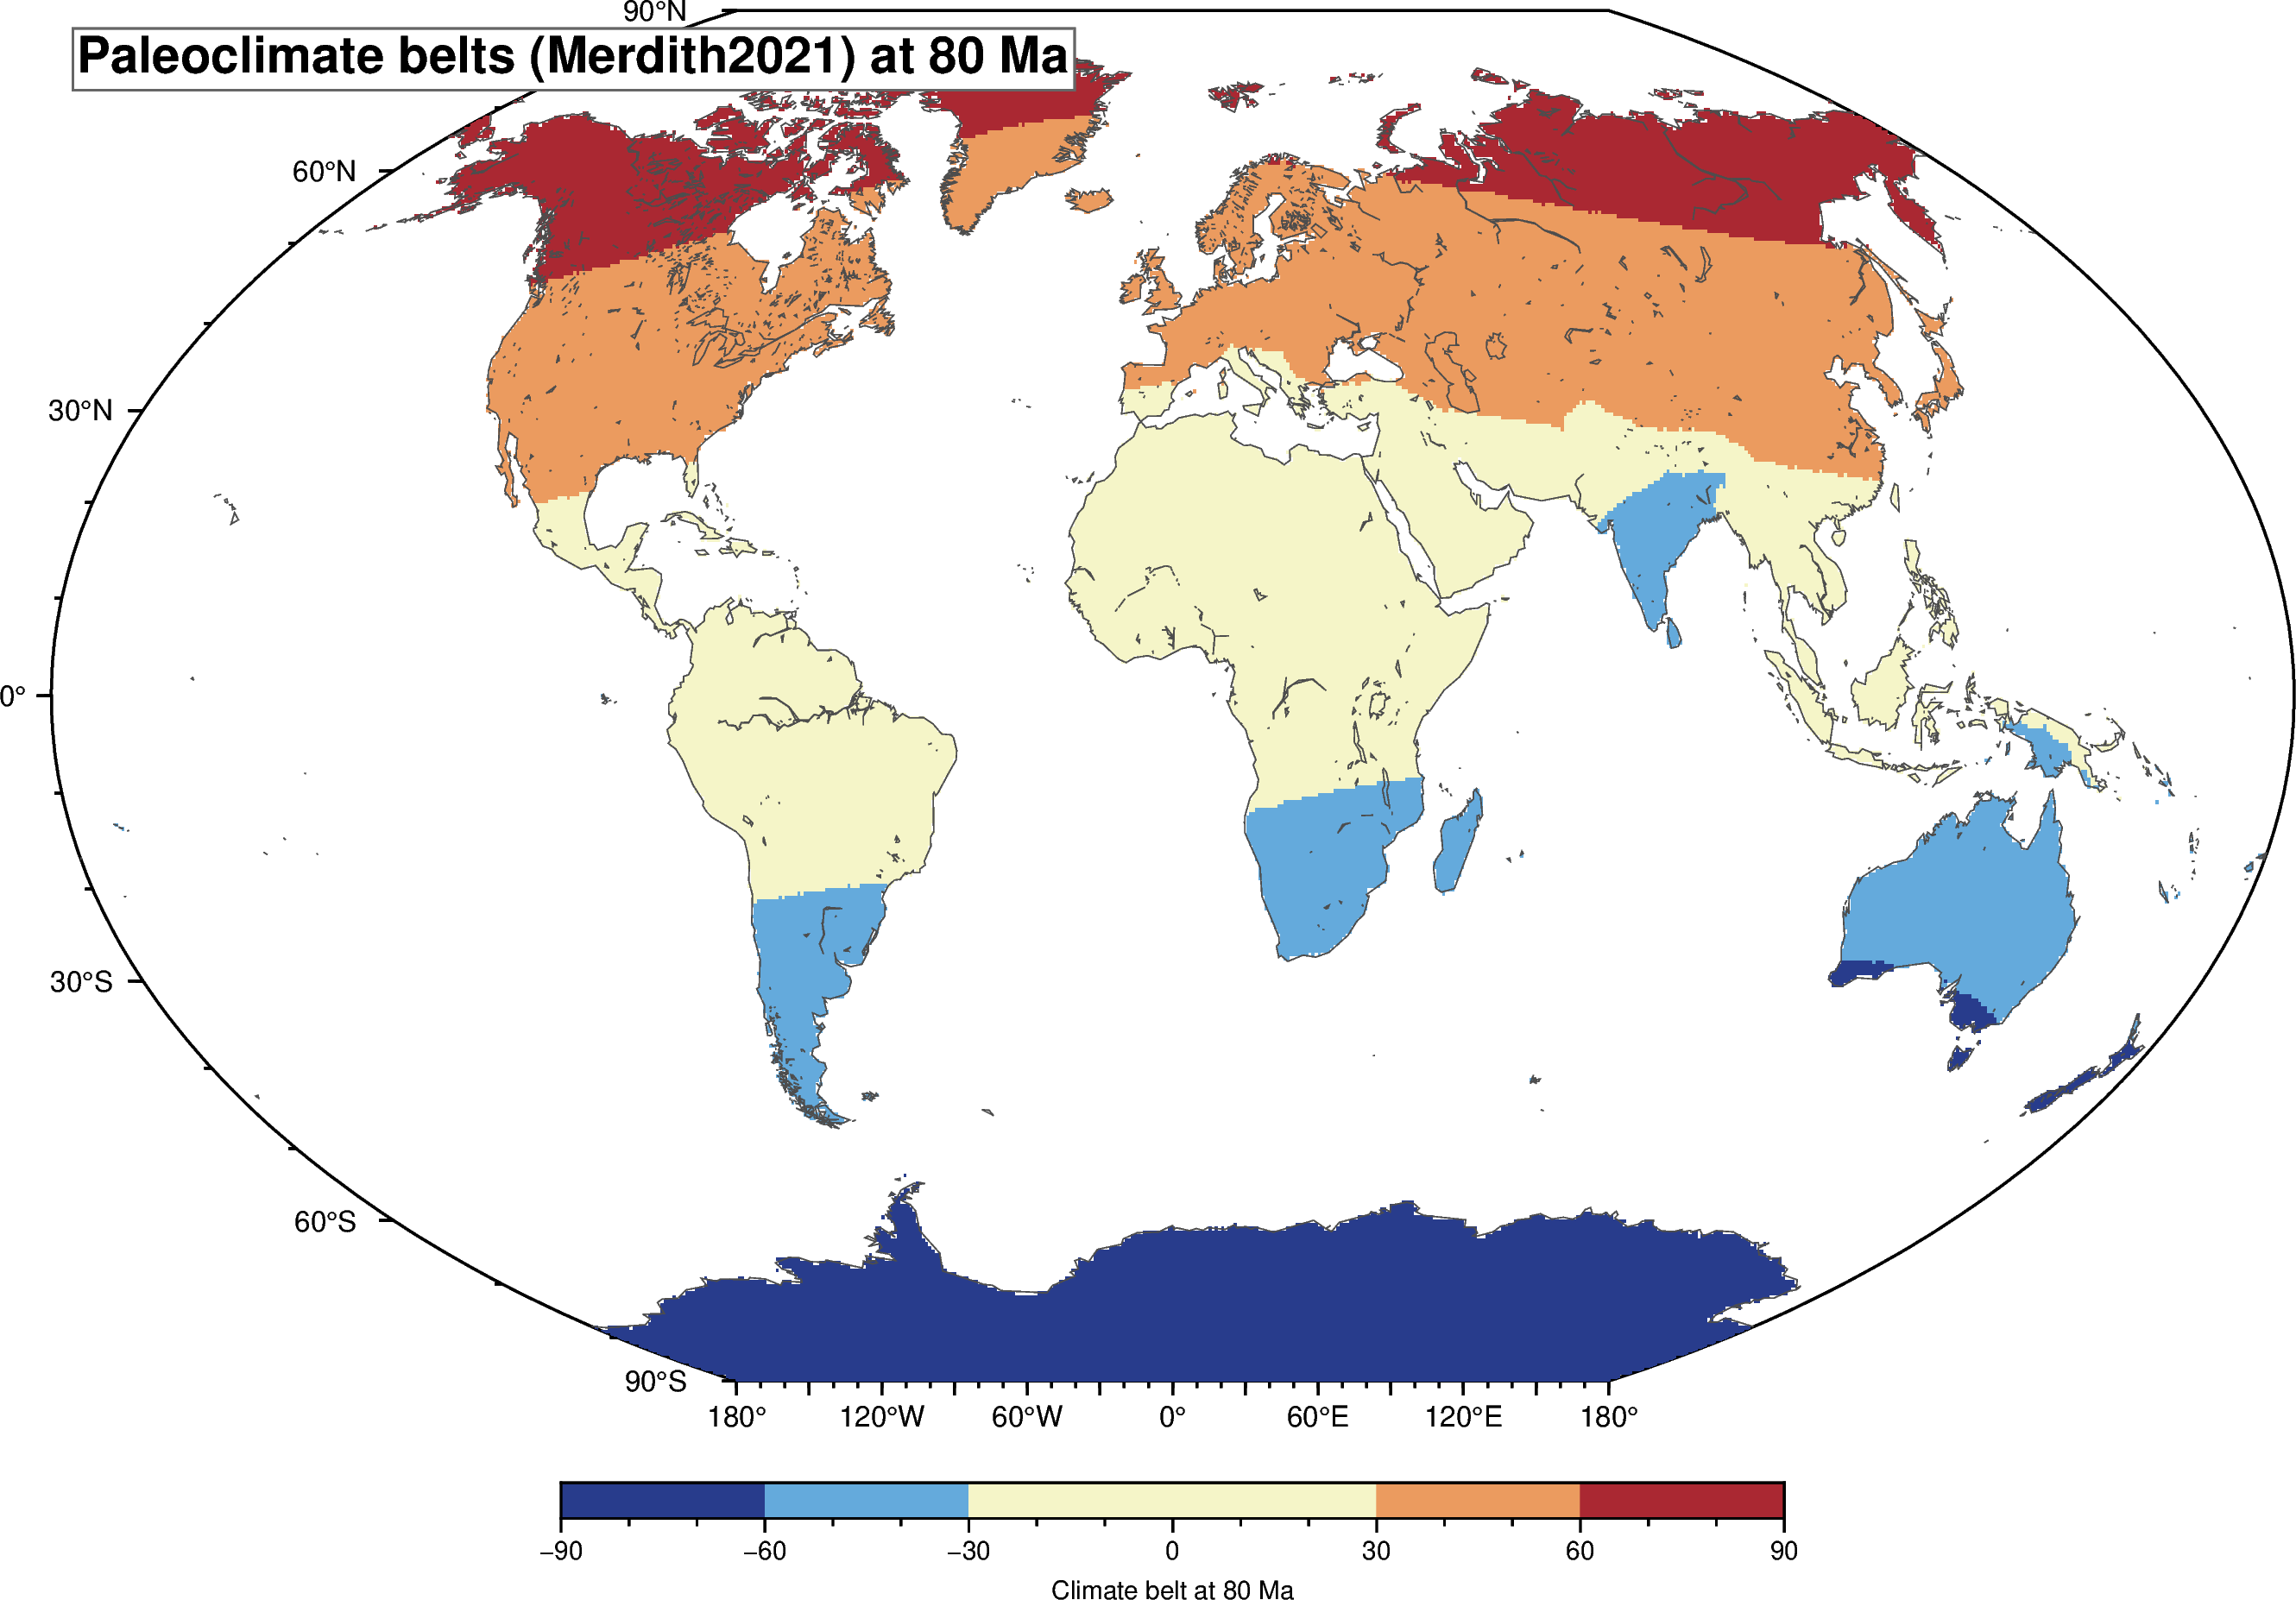

In [10]:
from pathlib import Path
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
# 5-step polar palette — breaks at [-90, -60, -30, +30, +60, +90]
_fd, cpt5 = tempfile.mkstemp(suffix=".cpt", prefix="T73_belts_")
os.close(_fd)
# Manually build the discrete CPT to match Kocsis's 5-belt scheme.
belt_lines = [
    "# COLOR_MODEL = RGB",
    "-90 40/60/140  -60 40/60/140",       # deep blue — southern polar
    "-60 100/170/220 -30 100/170/220",    # light blue — southern temperate
    "-30 245/245/200 +30 245/245/200",    # cream — tropical
    "+30 235/155/95  +60 235/155/95",     # orange — northern temperate
    "+60 170/40/50   +90 170/40/50",      # dark red — northern polar
    "B 20/40/100",
    "F 120/20/30",
    "N 200/200/200",
]
Path(cpt5).write_text("\n".join(belt_lines) + "\n")

fig.grdimage(grid=da_paleolat, cmap=cpt5, nan_transparent=True)
fig.coast(land=None, shorelines="0.3p,gray30")
fig.colorbar(cmap=cpt5, frame=["a30f10", f"x+lClimate belt at {PALEO_AGE_MA:.0f} Ma"],
             position="JBC+w12c/0.35c+h+o0/1c")
fig.text(text=f"Paleoclimate belts ({MODEL_NAME}) at {PALEO_AGE_MA:.0f} Ma",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 8. Bonus — the same information on a paleogeographic reconstruction at PALEO_AGE_MA

The three maps above show the reverse-reconstruction on the *modern* map. For completeness (and to satisfy the house-style rule that every notebook in this suite includes at least one reconstructed paleogeographic map), here's the same sample rendered on the **paleo-map** at PALEO_AGE_MA. This is essentially the *forward* view: every point sits at its actual paleo position, coloured by that same paleolatitude, on top of reconstructed continents.

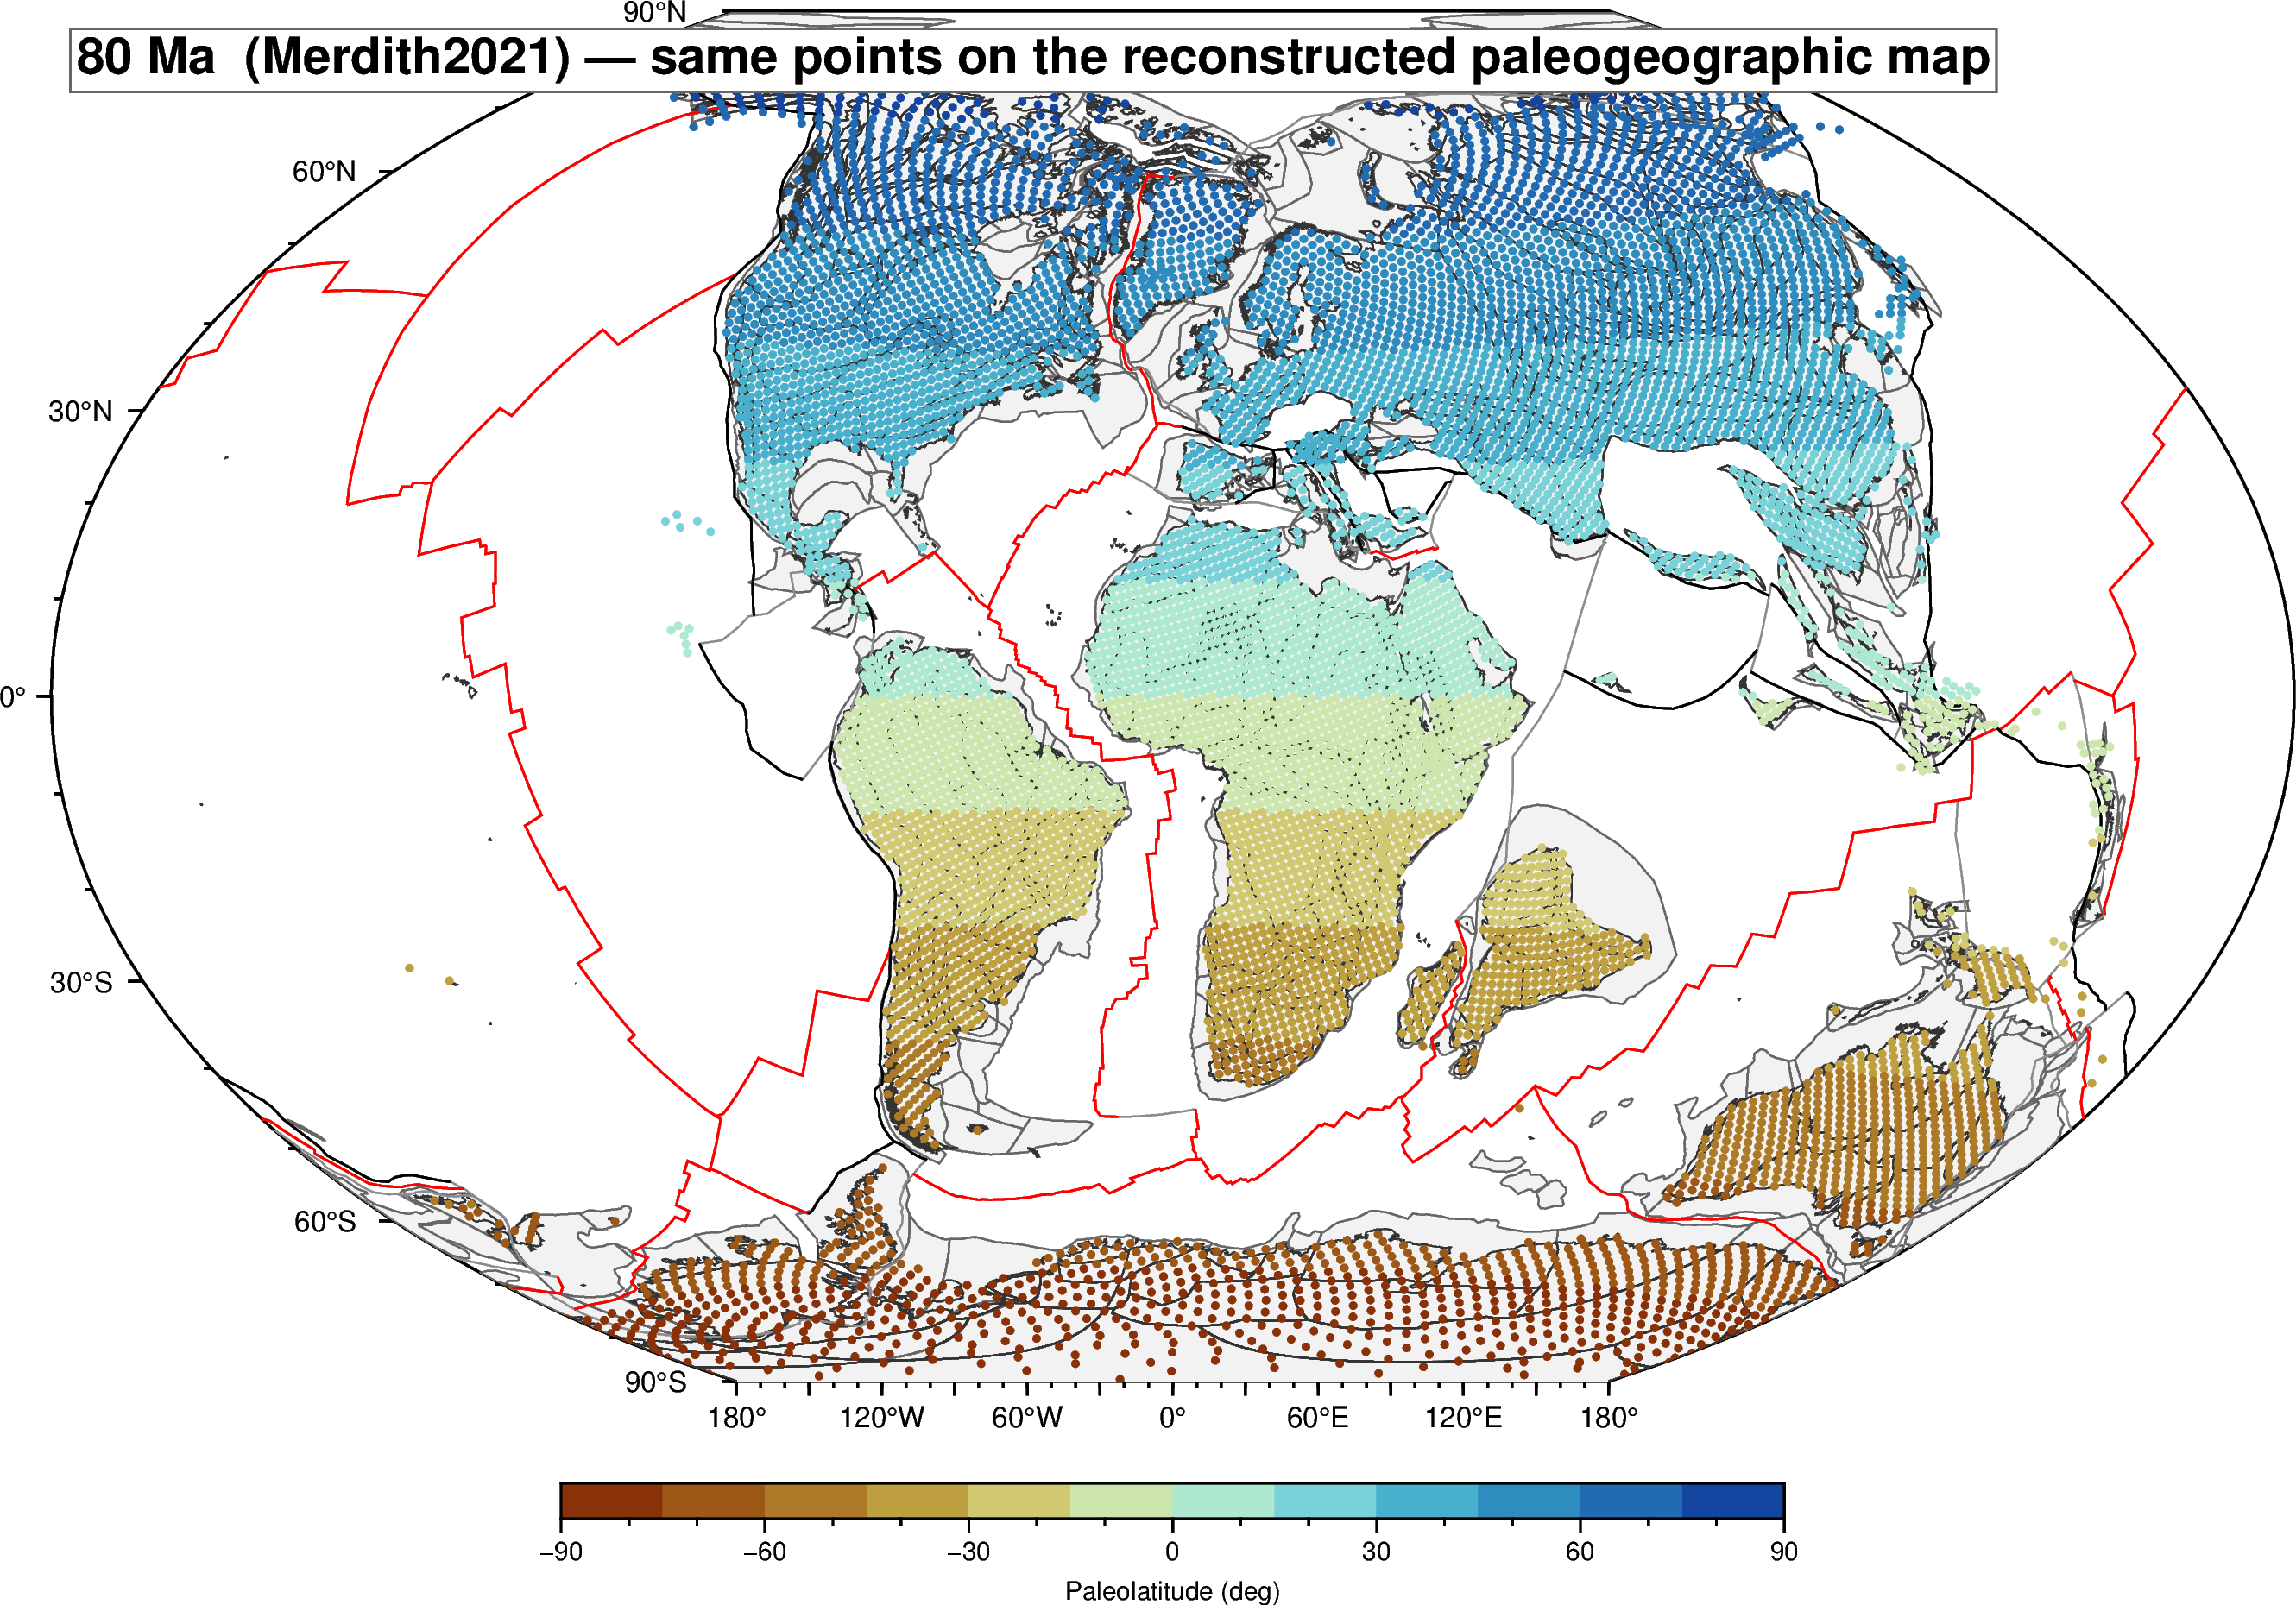

In [11]:
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    continents=model.get_layer("ContinentalPolygons"),
    plot_engine=gplately.PygmtPlotEngine(),
    time=float(PALEO_AGE_MA),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray40")
gplot.plot_coastlines(fig, pen="0.4p,gray20")
try:
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray55")
    gplot.plot_ridges(fig, pen="0.6p,red")
    gplot.plot_trenches(fig, pen="0.6p,black")
except Exception:
    pass

# Points at their PALEO positions, coloured by paleolatitude
xyz_paleo = np.column_stack([
    df_land["paleo_lon"].to_numpy(),
    df_land["paleo_lat"].to_numpy(),
    df_land["paleo_lat"].to_numpy(),
])
pygmt.makecpt(cmap="roma", series=[-90, 90, 15])
fig.plot(data=xyz_paleo, style="c0.08c", cmap=True)
fig.colorbar(frame=["a30f10", f"x+lPaleolatitude (deg)"],
             position="JBC+w12c/0.35c+h+o0/1c")
fig.text(text=f"{PALEO_AGE_MA:.0f} Ma  ({MODEL_NAME}) — same points on the reconstructed paleogeographic map",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## Extend this

- **Sweep through time.** Wrap the whole reverse-reconstruction + IDW pipeline in a loop over PALEO_AGE_MA ∈ [0, 5, 10, ...] and animate to see paleolatitude bands drift across today's continents.
- **Swap the plate model.** Try `Zahirovic2022` with anchor 701701 (Phanerozoic paleomag frame; capped at 410 Ma), or the mantle-frame `Muller2019`/`Cao2024` — the paleoclimate reading changes significantly (see T35 for the frame-uncertainty argument).
- **Highlight climate-belt crossings.** Compute the difference between modern latitude and paleolatitude — map the drift in degrees to see which continents crossed climate zones since PALEO_AGE_MA.
- **Constrain by biogeography.** Overlay Boucot climate-sensitive lithologies (T62) or PBDB fossil occurrences (T60) on the belt map — do the fossil-inferred climate zones match the plate model's paleolatitude prediction?
- **Use s2geometry rather than Fibonacci sampling.** For higher spatial resolution at controlled sizes, replace the Fibonacci lattice with s2geometry cells (or H3 hexagons — see T61).

## Related notebooks

- **T02** — GPlates Web Service Python: the lightest-weight introduction to reverse reconstruction of individual points via HTTP-REST.
- **T33–T42** — the paleomagnetism cluster: T33 builds a reference frame from GPMDB, T35 shows how much paleolatitude depends on frame choice.
- **T68–T71** — Leonard reference-frame quartet: uses the same reverse-reconstruction idea to compare paleolatitude across three frames.

## References

- Kocsis, A. (2026). `pyGMTexamples/paleolat.R`. https://github.com/adamkocsis/pyGMTexamples
- Kocsis, A.T. (2020). rgplates: R interface for the GPlates web service and desktop application. https://gplates.github.io/rgplates/
- Merdith, A.S., Williams, S.E., Collins, A.S., Tetley, M.G., Mulder, J.A., Blades, M.L., Young, A., Armistead, S.E., Cannon, J., Zahirovic, S. & Müller, R.D. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477. https://doi.org/10.1016/j.earscirev.2020.103477
- Müller, R.D. et al. (2018). GPlates: Building a virtual Earth through deep time. *Geochemistry, Geophysics, Geosystems* 19, 2243–2261. https://doi.org/10.1029/2018GC007584
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
